# Notebook to train models / run sweeps


In [1]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from Trainer import *
from mesh import *
from baseline import *
from metrics import *
import os
#from main import *
import numpy as np
import matplotlib.pyplot as plt

e:\VSCodium\OML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initialization of Mesh parameters

### Random initialisation

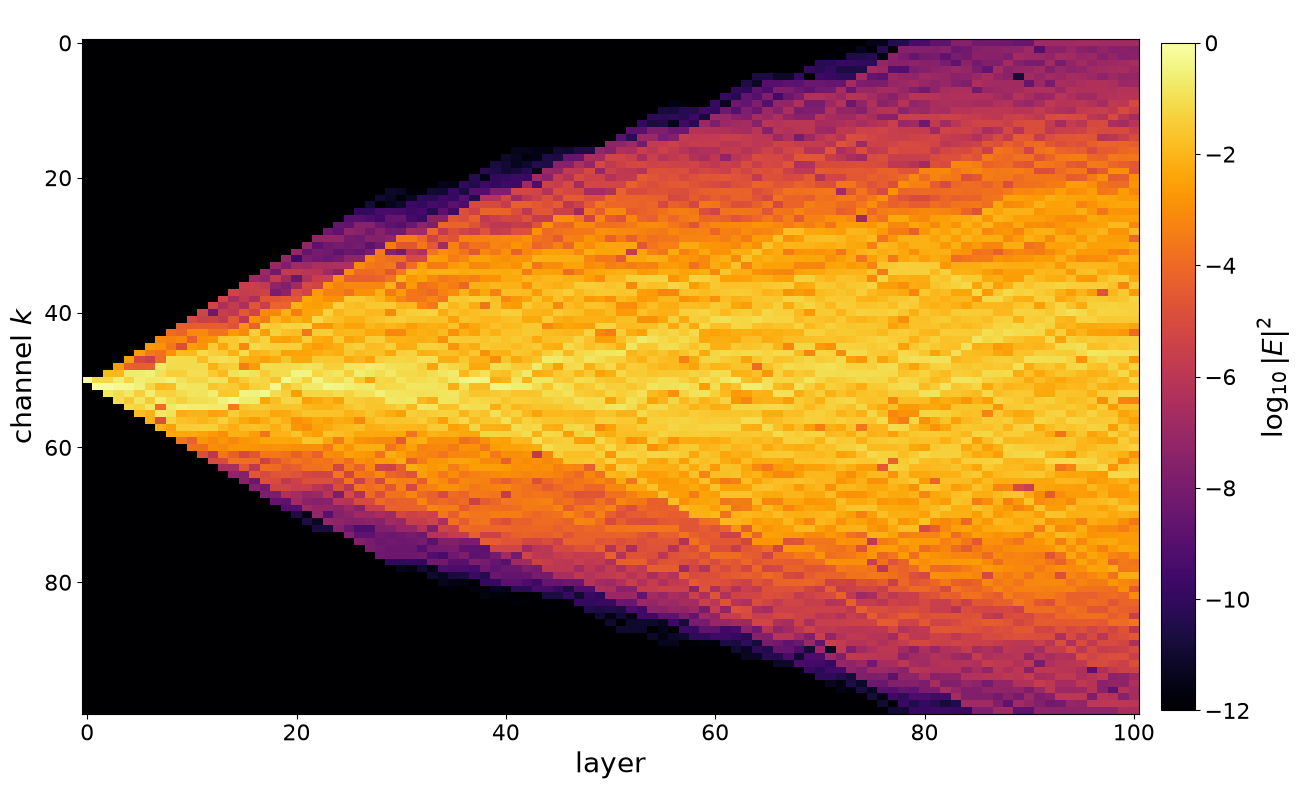

In [12]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters
E_train=np.zeros(100)
E_train[50]=1
E_out  = forward(E_train, layers)         #propagation that gives end result directly

E_hist = forward_history(E_train, layers) #propagation that gives all E-fields for every layer

#Calculating and plotting intensity for one specific batch (2)
I = np.abs(E_hist[:,:])**2
fig, _ = plot_intensity_map(I, log=True, title=r" ", label_fontsize=20, tick_fontsize=16)

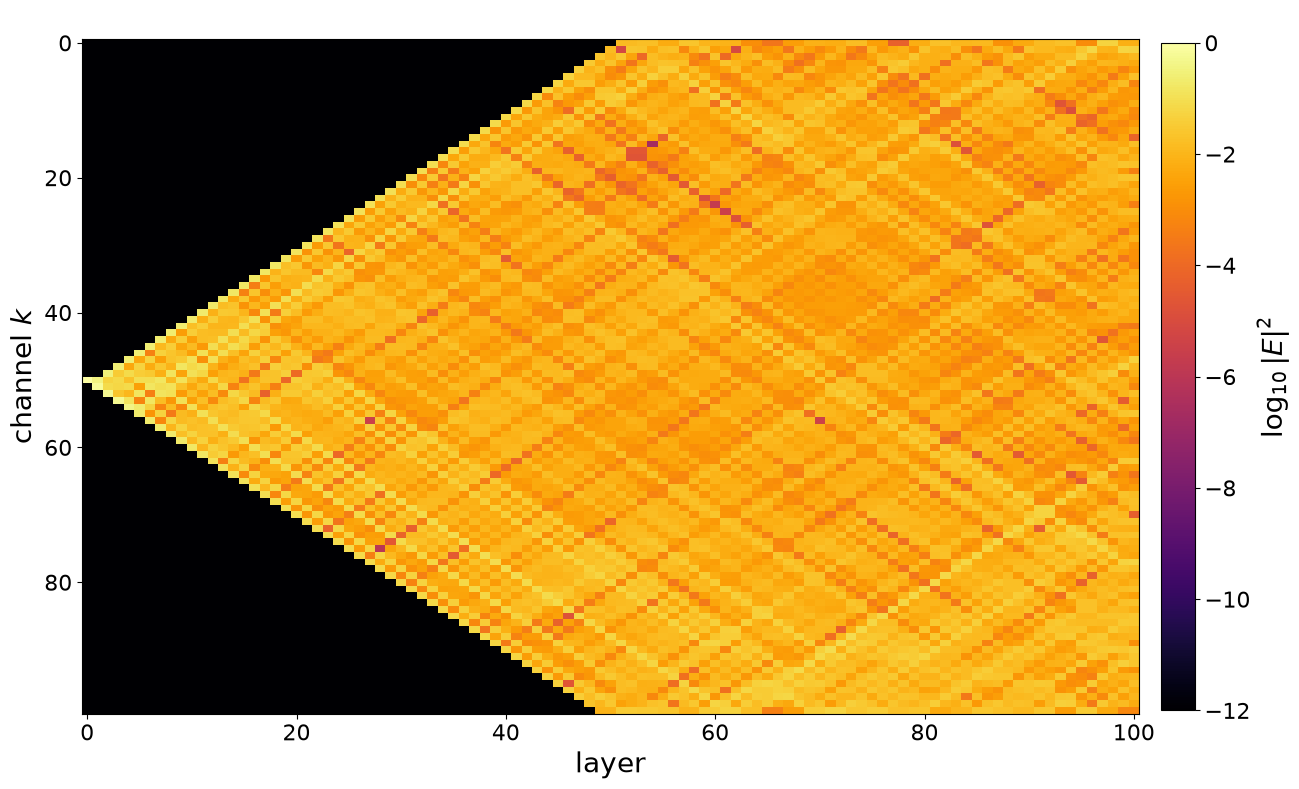

In [13]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_haar() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters
E_train=np.zeros(100)
E_train[50]=1
E_out  = forward(E_train, layers)         #propagation that gives end result directly

E_hist = forward_history(E_train, layers) #propagation that gives all E-fields for every layer

#Calculating and plotting intensity for one specific batch (2)
I = np.abs(E_hist[:,:])**2
fig, _ = plot_intensity_map(I, log=True, title=r" ", label_fontsize=20, tick_fontsize=16)

## Convergence Comparisson between both init.

In [8]:
#Sweep Array:
sweep = ["random", "haar"] 
values=np.array([1,7])               
sweep_label="init. type"                  
learnig_rate=1.3
batch_size=64
m=10
detector_positions=(33,66)

#Perform training
trainers = []
for s in sweep:
    cfg = TrainConfig(m_side=m, theta_enc=1, normalize_energy=True, encoding='amplitude', 
            detectors=detector_positions, loss_kind='mse', learning_rate=learnig_rate, batch_size=batch_size,
                      init=s, max_epochs=35, patience=5, min_delta=1e-4,     #patience=2 und min_delta=1e-4 hat sich für mich jetzt gut ergeben, vielleicht sogar nur 1e-3
                      param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)
    E_tr, y_tr, E_te, y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
    t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
    t.fit(E_tr, y_tr)
    t.test_acc = t.evaluate(E_te, y_te)[1]  
    t.save(f"results/{sweep_label}/{s}.json", test_acc=t.test_acc)
    trainers.append(t)


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 29.00/35 | Loss: 0.2047:  83%|████████▎ | 725/875.0 [05:54<01:13,  2.04it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.1651:  46%|████▌     | 400/875.0 [03:05<03:40,  2.16it/s]


## Length of Mesh

In [ ]:
def training_sweep_layer_count(sweep_param, values, number, m, theta_enc, normalize_energy,
                      param_init_seed, balanced, split_ratio, encoding,
                      detectors, loss_kind, learning_rate, batch_size,
                      init, max_epochs, patience, min_delta,
                      eta_bs, alpha_fiber, verbose):
    
    sweep = sweep_param[0]
    sweep_label = sweep_param[1]

    # Perform training
    trainers = []
    for s in sweep:
        cfg = TrainConfig(m, theta_enc, normalize_energy, encoding,
                          detectors, loss_kind, learning_rate, batch_size,
                          init, max_epochs, patience, min_delta,
                          param_init_seed, eta_bs, alpha_fiber)
        E_tr, y_tr, E_te, y_te = get_data(values, number, m,
                                          theta_enc, normalize_energy,
                                          param_init_seed, verbose)
        t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, s)), cfg) #sweep over layer
        t.fit(E_tr, y_tr)
        t.test_acc = t.evaluate(E_te, y_te)[1]
        t.save(f"results/{sweep_label}/{s}.json", test_acc=t.test_acc)
        trainers.append(t)

    # Plot trainingresults
    fig, _ = plot_training(trainers, sweep, keys=(
        "batch_loss", "loss", "acc", "grad_norm"), sweep_label=sweep_label)

    for s, t in zip(sweep, trainers):
        print(f"m={m:3d}  N={m*m:4d}  epochs={len(t.history['loss']):3d}  "
              f"loss={t.history['loss'][-1]:.5f}  "
              f"train acc={t.history['acc'][-1]:.4f}  "
              f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

    fig.savefig(f"results/{sweep_label}/plot_training.png",
                dpi=600, bbox_inches='tight')

Train:  1600 samples, class counts {1: 814, 7: 786}
Test :   400 samples, class counts {1: 203, 7: 197}


Epoch 10.00/10 | Loss: 0.8099: 100%|██████████| 250/250.0 [00:11<00:00, 20.96it/s]


m= 10  N= 100  epochs= 10  loss=0.81487  train acc=0.5856  test acc=0.5875  12s


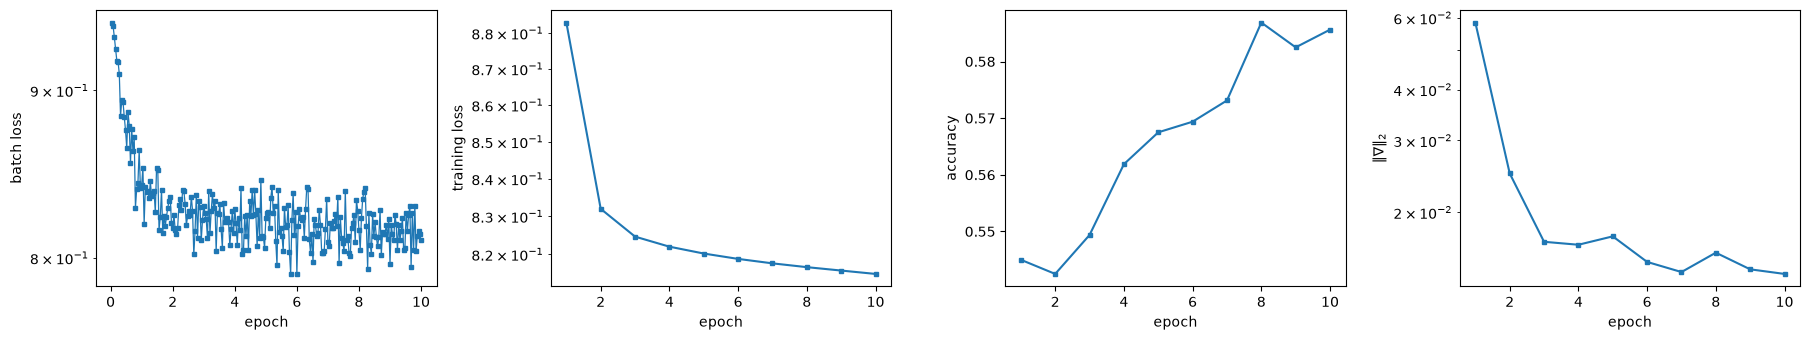

In [ ]:
# Set standard parameters
values = np.array([1, 7])  # digits you want from the mnist dataset
number = 2000  # Sets number of samples you want to get in total
m = 10  # side length (pixel) of mnist image after downsampling
norm_energy = True  # Bool for if energy of encoded image should be normalized or not
seed = 1550  # Random seed to control random choice of number -pictures out of the available ones,
# seed = None leads to random results for each iteration
balanced = True  # Enforcing equality of classes
split_ratio = 0.8  # Sets training-sample proportion
verbose = False

# Standard parameters specific to OML system
theta_enc = 1
encoding = 'amplitude'
detectors = (33, 66)
loss_kind = 'mse'
learning_rate = 1.3
batch_size = 64
init = "haar"
max_epochs = 10
patience = 1
min_delta = 1e-4
eta_bs = 1.0
alpha_fiber = 0.0


sweep = np.array([10,50,100,150,200])
sweep_label = "layer count"

training_sweep_layer_count((sweep, sweep_label), values, number, m, theta_enc, norm_energy,
                        seed, balanced, split_ratio, encoding,
                        detectors, loss_kind, learning_rate, batch_size,
                        init, max_epochs, patience, min_delta,
                        eta_bs, alpha_fiber, verbose)

## Sidelength m

In [26]:
def training_sweep_m_sidelength(values, number, theta_enc, normalize_energy,
                      param_init_seed, balanced, split_ratio, encoding,
                      detectors, loss_kind, learning_rate, batch_size,
                      init, max_epochs, patience, min_delta,
                      eta_bs, alpha_fiber, verbose):
    
    # Sweep Array:
    sweep = [6,8,10,14,18,22]
    sweep_label = "m_sidelength2"


    # Perform training
    trainers = []
    for s in sweep:
        detectors=(int((1/3)*(s**2)),int((2/3)*(s**2))) #detectors are set to 1/3 and 2/3 of N
        cfg = TrainConfig(s, theta_enc, normalize_energy, encoding,
                          detectors, loss_kind, learning_rate, batch_size,
                          init, max_epochs, patience, min_delta,
                          param_init_seed, eta_bs, alpha_fiber)
        E_tr, y_tr, E_te, y_te = get_data(values, number, s,
                                                    theta_enc, normalize_energy, param_init_seed, balanced, split_ratio, verbose)
        t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
        t.fit(E_tr, y_tr)
        t.test_acc = t.evaluate(E_te, y_te)[1]
        t.save(f"results/{sweep_label}/{s}.json", test_acc=t.test_acc)
        trainers.append(t)

    # Plot training results
    fig, _ = plot_training(trainers, sweep, keys=(
        "batch_loss", "loss", "acc", "grad_norm"), sweep_label=sweep_label)

    for s, t in zip(sweep, trainers):
        print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d}"
              f"loss={t.history['loss'][-1]:.5f}  "
              f"train acc={t.history['acc'][-1]:.4f}  "
              f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

    plt.savefig(f"results/{sweep_label}/plot_training.png",
                dpi=600, bbox_inches='tight')



Epoch 9.00/10 | Loss: 0.1991:  90%|█████████ | 225/250.0 [00:09<00:01, 22.53it/s]
Epoch 10.00/10 | Loss: 0.2075: 100%|██████████| 250/250.0 [01:01<00:00,  4.05it/s]
Epoch 8.00/10 | Loss: 0.1681:  80%|████████  | 200/250.0 [01:43<00:25,  1.94it/s]
Epoch 9.00/10 | Loss: 0.2108:  90%|█████████ | 225/250.0 [08:39<00:57,  2.31s/it]
Epoch 9.00/10 | Loss: 0.2332:  90%|█████████ | 225/250.0 [23:18<02:35,  6.21s/it]
Epoch 9.00/10 | Loss: 0.2361:  90%|█████████ | 225/250.0 [55:06<06:07, 14.70s/it]  


m_sidelength2=6  epochs=  9loss=0.22204  train acc=0.8956  test acc=0.9325  10s
m_sidelength2=8  epochs= 10loss=0.18389  train acc=0.9669  test acc=0.9600  62s
m_sidelength2=10  epochs=  8loss=0.19697  train acc=0.9681  test acc=0.9775  103s
m_sidelength2=14  epochs=  9loss=0.21509  train acc=0.9712  test acc=0.9875  519s
m_sidelength2=18  epochs=  9loss=0.24516  train acc=0.9675  test acc=0.9775  1398s
m_sidelength2=22  epochs=  9loss=0.24688  train acc=0.9637  test acc=0.9800  3307s


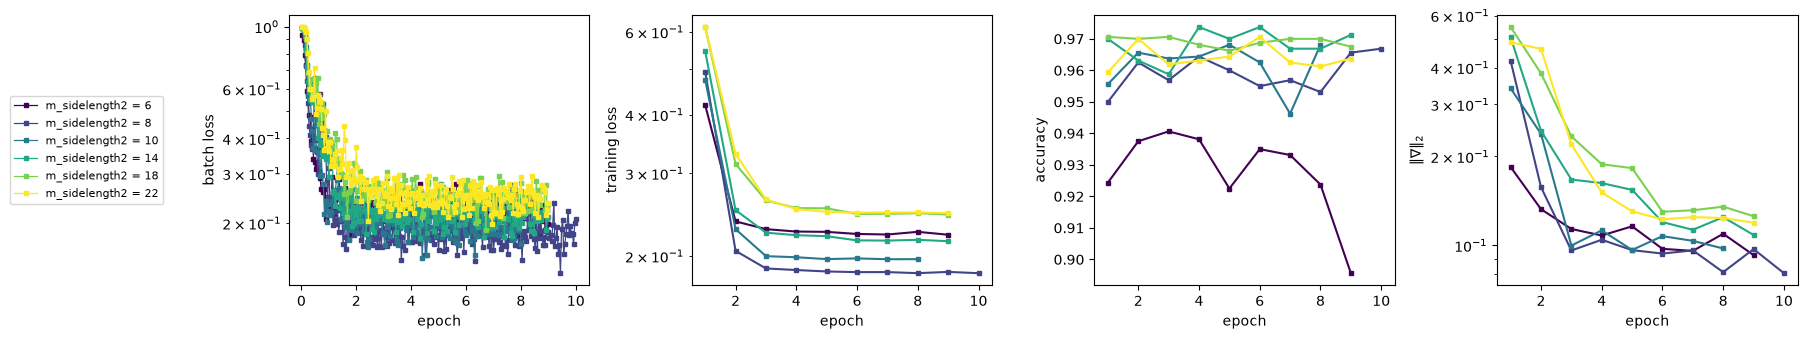

In [27]:
# Set standard parameters
values = np.array([1, 7])  # figures you want from the mnist dataset
number = 2000  # Sets number of samples you want to get in total
# mysterious hyper parameter for amplitude scaling
norm_energy = True  # Bool for if energy of encoded image should be normalized or not
seed = 1550  # Random seed to control random choice of number -pictures out of the available ones,
# seed = None leads to random results for each iteration
balanced = True  # Enforcing equality of classes
split_ratio = 0.8  # Sets training-sample proportion
verbose = False

# Standard parameters specific to OML system
theta_enc = 1
encoding = 'amplitude'
detectors = (33, 66)
loss_kind = 'mse'
learning_rate = 1.3
batch_size = 64
init = "haar"
max_epochs = 10
patience = 3
min_delta = 1e-3
eta_bs = 1.0
alpha_fiber = 0.0

training_sweep_m_sidelength(values, number, theta_enc, norm_energy,
                        seed, balanced, split_ratio, encoding,
                        detectors, loss_kind, learning_rate, batch_size,
                        init, max_epochs, patience, min_delta,
                        eta_bs, alpha_fiber, verbose)

## Learning rate

In [11]:
#Sweep Array:
sweep = [0.8,0.9,1.0,1.1,1.3,1.5,1.7] 
#sweep = [2.2,2.5,2.7] 
values=np.array([1,7])               
sweep_label="learning_rate"                  

#Perform training
trainers = []
for s in sweep:
    cfg = TrainConfig(m_side=m, theta_enc=1, normalize_energy=True, encoding='amplitude', 
            detectors=detector_positions, loss_kind='mse', learning_rate=s, batch_size=64,
                      init=init, max_epochs=35, patience=5, min_delta=1e-4,     #patience=2 und min_delta=1e-4 hat sich für mich jetzt gut ergeben, vielleicht sogar nur 1e-3
                      param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)
    E_tr, y_tr, E_te, y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
    t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
    t.fit(E_tr, y_tr)
    t.test_acc = t.evaluate(E_te, y_te)[1]  
    t.save(f"results/{sweep_label}/{s:.3f}.json", test_acc=t.test_acc)
    trainers.append(t)


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.1648:  46%|████▌     | 400/875.0 [05:17<06:16,  1.26it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.1648:  46%|████▌     | 400/875.0 [06:11<07:20,  1.08it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


...

Epoch 16.00/35 | Loss: 0.1651:  46%|████▌     | 400/875.0 [02:24<02:51,  2.77it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.1655:  46%|████▌     | 400/875.0 [02:22<02:49,  2.81it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.1655:  46%|████▌     | 400/875.0 [02:21<02:48,  2.83it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}
learning_rate=0.8  epochs= 16 loss=0.19447  train acc=0.9675  test acc=0.9700  317s
learning_rate=1.0  epochs= 16 loss=0.19505  train acc=0.9681  test acc=0.9700  207s
learning_rate=1.3  epochs= 16 loss=0.19596  train acc=0.9681  test acc=0.9700  144s
learning_rate=1.5  epochs= 16 loss=0.19645  train acc=0.9681  test acc=0.9700  142s


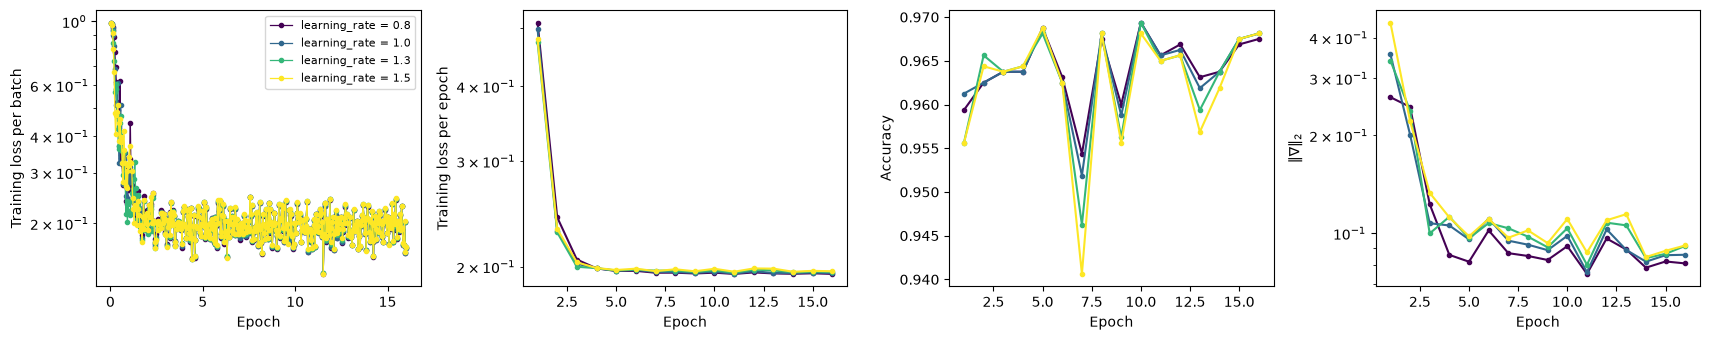

In [16]:
#%%All data
#Standard variables
init="haar"
sweep_label="learning_rate" 
m = 10
detector_positions = (33, 66)
sweep = [0.01, 0.03, 0.1, 0.3, 0.8,0.9,1.0,1.1,1.3,1.5,1.7,2.2,2.5,2.7,3,4,5.0,10.0,50.0] 
sweep = [0.3, 0.8,1.0,1.3,1.7,2.2,2.5,2.7]
sweep = [ 0.8,1.0,1.3,1.5] 

values=np.array([1,7])
trainers = []
E_tr, Y_tr, E_te, Y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
for s in sweep:
    t = Trainer.load(os.path.join(os.getcwd(),f"results/{sweep_label}/{s:.3f}.json"))
    test_loss, test_acc = t.evaluate(E_te, Y_te)
    trainers.append(t)

for s, t in zip(sweep, trainers):
    print(f"{sweep_label}={s}  epochs={len(t.history['loss']):3d} "
          f"loss={t.history['loss'][-1]:.5f}  "
          f"train acc={t.history['acc'][-1]:.4f}  "
          f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

#Plot trainingresults
fig, _ = plot_training(trainers, sweep, keys=("batch_loss", "loss", "acc", "grad_norm"), sweep_label=sweep_label)



Learning Rate for bigger batch size

In [20]:
#Sweep Array:
sweep = [0.03,1.0,1.3,1.7,5,10] 

#sweep = [2.2,2.5,2.7] 
values=np.array([1,7])               
sweep_label="learning_rate_bigger_batchsize"                  

#Perform training
trainers = []
for s in sweep:
    cfg = TrainConfig(m_side=m, theta_enc=1, normalize_energy=True, encoding='amplitude', 
            detectors=detector_positions, loss_kind='mse', learning_rate=s, batch_size=256,
                      init=init, max_epochs=35, patience=5, min_delta=1e-4,     #patience=2 und min_delta=1e-4 hat sich für mich jetzt gut ergeben, vielleicht sogar nur 1e-3
                      param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)
    E_tr, y_tr, E_te, y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
    t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
    t.fit(E_tr, y_tr)
    t.test_acc = t.evaluate(E_te, y_te)[1]  
    t.save(f"results/{sweep_label}/{s:.3f}.json", test_acc=t.test_acc)
    trainers.append(t)


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 35.00/35 | Loss: 0.4034: 100%|██████████| 245/245.0 [02:33<00:00,  1.59it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 27.00/35 | Loss: 0.1961:  77%|███████▋  | 189/245.0 [02:09<00:38,  1.45it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


...

Epoch 14.00/35 | Loss: 0.1872:  40%|████      | 98/245.0 [01:11<01:46,  1.38it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 13.00/35 | Loss: 0.9632:  37%|███▋      | 91/245.0 [01:03<01:47,  1.44it/s]


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 16.00/35 | Loss: 0.9076:  46%|████▌     | 112/245.0 [01:18<01:33,  1.42it/s]


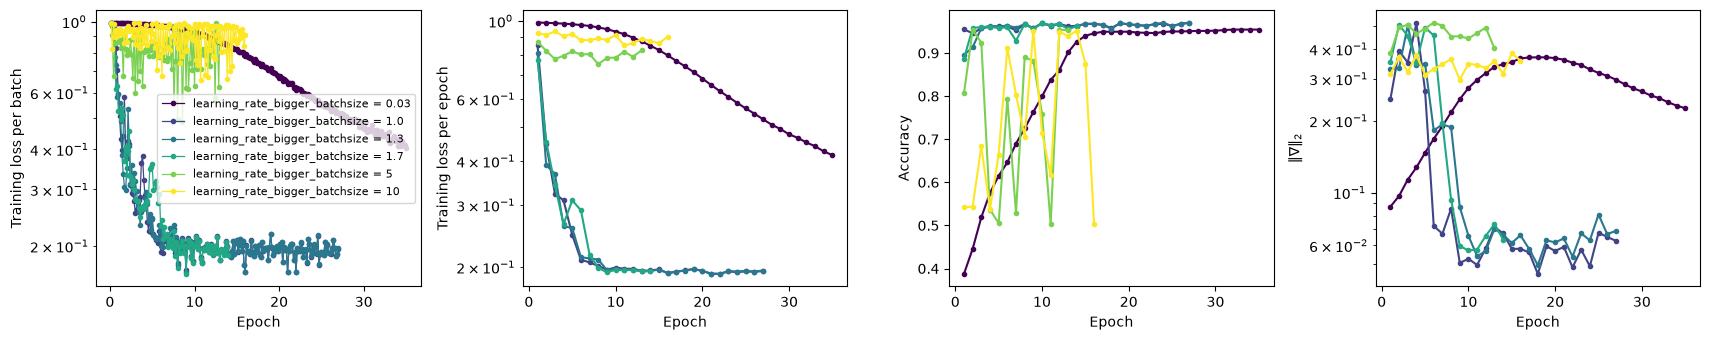

In [18]:
fig, _ = plot_training(trainers, sweep, keys=("batch_loss", "loss", "acc", "grad_norm"), sweep_label=sweep_label)



Learning rate for smaller batch size

In [19]:
#Sweep Array:
sweep = [0.03,1.0,1.3,1.7,5,10] 

#sweep = [2.2,2.5,2.7] 
values=np.array([1,7])               
sweep_label="learning_rate_smaller_batchsize"                  

#Perform training
trainers = []
for s in sweep:
    cfg = TrainConfig(m_side=m, theta_enc=1, normalize_energy=True, encoding='amplitude', 
            detectors=detector_positions, loss_kind='mse', learning_rate=s, batch_size=4,
                      init=init, max_epochs=35, patience=5, min_delta=1e-4,     #patience=2 und min_delta=1e-4 hat sich für mich jetzt gut ergeben, vielleicht sogar nur 1e-3
                      param_init_seed=1550, eta_bs=1.0, alpha_fiber=0.0)
    E_tr, y_tr, E_te, y_te = get_data(values, number=2000, m_side=m,
                                      theta_enc=1, normalize_energy=True,
                                      seed=1550, balanced=True, verbose=True)
    t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
    t.fit(E_tr, y_tr)
    t.test_acc = t.evaluate(E_te, y_te)[1]  
    t.save(f"results/{sweep_label}/{s:.3f}.json", test_acc=t.test_acc)
    trainers.append(t)


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 26.00/35 | Loss: 0.1909:  74%|███████▍  | 10400/14000.0 [32:13<11:09,  5.38it/s] 


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 32.00/35 | Loss: 0.1842:  91%|█████████▏| 12800/14000.0 [39:52<03:44,  5.35it/s] 


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


...

Epoch 21.00/35 | Loss: 0.1252:  60%|██████    | 8400/14000.0 [26:15<17:30,  5.33it/s]  


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 7.00/35 | Loss: 0.8572:  20%|██        | 2800/14000.0 [08:40<34:43,  5.38it/s]  


Train:  1600 samples, class counts {1: 800, 7: 800}
Test :   400 samples, class counts {1: 200, 7: 200}


Epoch 6.00/35 | Loss: 0.9587:  17%|█▋        | 2400/14000.0 [07:27<36:04,  5.36it/s]  


## Loss functions 

In [24]:
values = np.array([1, 7])  # digits you want from the mnist dataset
number = 2000  # Sets number of samples you want to get in total
m = 10  # side length (pixel) of mnist image after downsampling
norm_energy = True  # Bool for if energy of encoded image should be normalized or not
seed = 1550  # Random seed to control random choice of number -pictures out of the available ones,
# seed = None leads to random results for each iteration
balanced = True  # Enforcing equality of classes
split_ratio = 0.8  # Sets training-sample proportion
verbose = False

# Standard parameters specific to OML system
theta_enc = 1
encoding = 'amplitude'
detectors = (33, 66)
learning_rate = 1.0
batch_size = 64
loss_kind="mse"
init = "haar"
max_epochs = 20
patience = 8
min_delta = 1e-4
eta_bs = 1.0
alpha_fiber = 0.0

In [22]:
def training_sweep_loss_funct(sweep_param, values, number, m, theta_enc, normalize_energy,
                      param_init_seed, balanced, split_ratio, encoding,
                      detectors, loss_kind, learning_rate, batch_size,
                      init, max_epochs, patience, min_delta,
                      eta_bs, alpha_fiber, verbose):
    
    sweep = sweep_param[0]
    sweep_label = sweep_param[1]

    # Perform training
    trainers = []
    for s in sweep:
        cfg = TrainConfig(m, theta_enc, normalize_energy, encoding,
                          detectors, s, learning_rate, batch_size, #s for loss_kind
                          init, max_epochs, patience, min_delta,
                          param_init_seed, eta_bs, alpha_fiber)
        E_tr, y_tr, E_te, y_te = get_data(values, number, m,
                                          theta_enc, normalize_energy,
                                          param_init_seed, balanced, split_ratio, verbose)
        t = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)
        t.fit(E_tr, y_tr)
        t.test_acc = t.evaluate(E_te, y_te)[1]
        t.save(f"results/{sweep_label}/{s}.json", test_acc=t.test_acc)
        trainers.append(t)

    # Plot trainingresults
    fig, _ = plot_training(trainers, sweep, keys=(
        "batch_loss", "loss", "acc", "grad_norm"), sweep_label=sweep_label)

    for s, t in zip(sweep, trainers):
        print(f"m={m:3d}  N={m*m:4d}  epochs={len(t.history['loss']):3d}  "
              f"loss={t.history['loss'][-1]:.5f}  "
              f"train acc={t.history['acc'][-1]:.4f}  "
              f"test acc={t.test_acc:.4f}  {t.train_time:.0f}s")

    fig.savefig(f"results/{sweep_label}/plot_training.png",
                dpi=600, bbox_inches='tight')

Epoch 13.00/20 | Loss: 0.1791:  65%|██████▌   | 325/500.0 [02:41<01:27,  2.01it/s]
Epoch 13.00/20 | Loss: 0.4741:  65%|██████▌   | 325/500.0 [02:41<01:26,  2.02it/s]


m= 10  N= 100  epochs= 13  loss=0.19523  train acc=0.9619  test acc=0.9700  162s
m= 10  N= 100  epochs= 13  loss=0.48085  train acc=0.9600  test acc=0.9675  161s


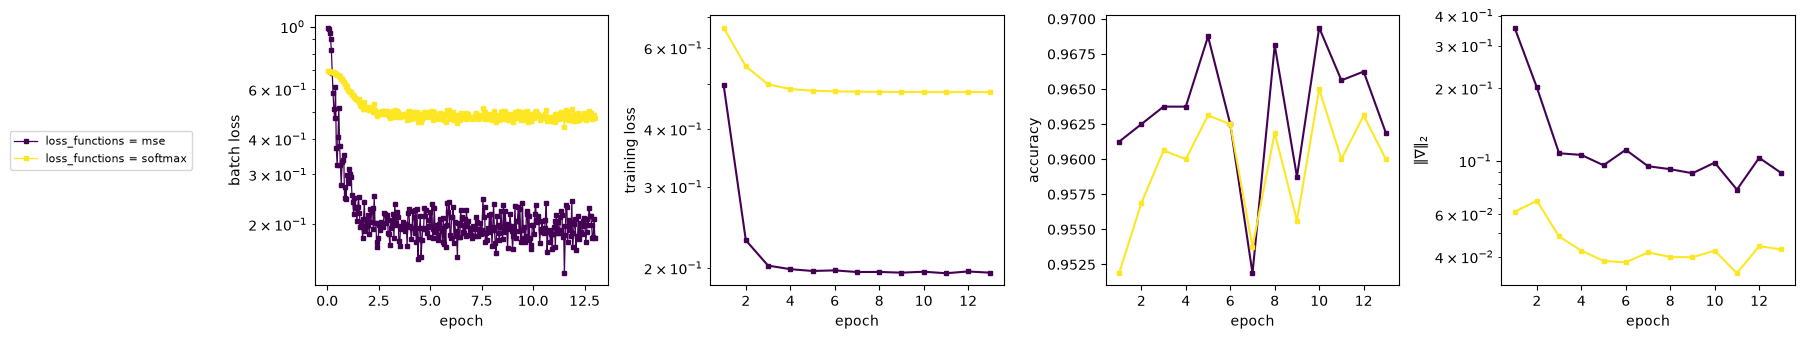

In [23]:
sweep = ["mse", "softmax"]
sweep_label = "loss_functions"
training_sweep_loss_funct((sweep, sweep_label), values, number, m, theta_enc, norm_energy,
                        seed, balanced, split_ratio, encoding,
                        detectors, loss_kind, learning_rate, batch_size,
                        init, max_epochs, patience, min_delta,
                        eta_bs, alpha_fiber, verbose)

## Encoding in phase

## Animation

In [4]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import pathlib, shutil, time
from Trainer import _copy

In [18]:
from tqdm.auto import tqdm  # Falls noch nicht in der Datei vorhanden

def training_animate_intensity(anim_param, values, number, m, theta_enc,
                            normalize_energy, param_init_seed, balanced,
                            split_ratio, encoding, detectors, loss_kind,
                            learning_rate, batch_size, init, max_epochs,
                            patience, min_delta, eta_bs, alpha_fiber,
                            verbose, n_show=None, keep_frames=False):
    """Train and animate how the field intensity evolves inside the mesh.

    anim_param : (video_path, show_class, every, fps)
        video_path : output file, e.g. "results/animation/training.mp4"
                    (".gif" works as well)
        show_class : 1 or 7 -- only samples of this class are propagated
        every      : take a snapshot every n-th gradient step
        fps        : frames per second of the video
    n_show      : use only the first n samples of that class (None = all).
                Fewer samples make each frame much cheaper to compute.
    keep_frames : keep the PNG files next to the video instead of deleting them

    fit() is not used here because a snapshot is needed *between* the gradient
    steps; the bookkeeping below mirrors what fit() does, so the returned
    trainer has a complete history, train_time and test_acc afterwards.
    """
    video_path, show_class, every, fps = anim_param
    video_path = pathlib.Path(video_path)

    # ---------------- data, config, mesh ----------------
    E_train, Y_train, E_test, Y_test = get_data(
        values, number, m, theta_enc, normalize_energy,
        param_init_seed, balanced, split_ratio, verbose)

    cfg = TrainConfig(m, theta_enc, normalize_energy, encoding,
                    detectors, loss_kind, learning_rate, batch_size,
                    init, max_epochs, patience, min_delta,
                    param_init_seed, eta_bs, alpha_fiber)
    trainer = Trainer(MZIMesh(cfg.N, plan_rectangular(cfg.N, cfg.N)), cfg)

    # samples propagated for the frames -- one class only
    E_show = E_train[:, Y_train == show_class]
    if n_show is not None:
        E_show = E_show[:, :n_show]
    print(f"animating class {show_class}: {E_show.shape[1]} samples per frame")

    def snapshot():
        """Mean intensity map of the shown class at the current weights."""
        I = np.abs(forward_history(E_show, trainer._layers()))**2   # (L+1,N,B)
        return I.mean(axis=2)                                       # (L+1,N)

    # ---------------- training loop with snapshots ----------------
    n_train = E_train.shape[1]
    batches_per_epoch = int(np.ceil(n_train / cfg.batch_size))
    frames, epochs_at = [snapshot()], [0.0]      # frame 0 = untrained mesh
    best_loss, wait, step = np.inf, 0, 0
    best_params = (_copy(trainer.thetas), _copy(trainer.phis))
    t0 = time.perf_counter()

    # --- TQDM Fortschrittsbalken für das Training ---
    pbar_train = tqdm(range(cfg.max_epochs), desc="Training Epochs")
    for epoch in pbar_train:
        idx = trainer.rng.permutation(n_train)
        losses, norms = [], []
        for s in range(0, len(idx), cfg.batch_size):
            b = idx[s:s + cfg.batch_size]
            loss, gn = trainer.step(E_train[:, b], Y_train[b])
            losses.append(loss); norms.append(gn)
            trainer.history["batch_loss"].append(float(loss))
            step += 1
            if step % every == 0:
                frames.append(snapshot())
                # fractional epoch, same definition as the progress bar
                epochs_at.append(step / batches_per_epoch)

        current_loss = float(np.mean(losses))
        trainer.history["loss"].append(current_loss)
        trainer.history["acc"].append(trainer.evaluate(E_train, Y_train)[1])
        trainer.history["grad_norm"].append(float(np.mean(norms)))
        trainer.history["epoch_end_step"].append(step)

        if trainer.history["loss"][-1] < best_loss - cfg.min_delta:
            best_loss, wait = trainer.history["loss"][-1], 0
            best_params = (_copy(trainer.thetas), _copy(trainer.phis))
        else:
            wait += 1
            if wait >= cfg.patience:
                pbar_train.write(f"Early stopping at epoch {epoch} (patience reached).")
                break
                
        # Status am Balken updaten (sehr praktisch!)
        pbar_train.set_postfix(loss=f"{current_loss:.4f}", wait=f"{wait}/{cfg.patience}")
        
    pbar_train.close() # Balken sauber schließen

    trainer.thetas, trainer.phis = best_params
    trainer.train_time = time.perf_counter() - t0
    trainer.test_acc = trainer.evaluate(E_test, Y_test)[1]
    print(f"{len(frames)} frames | {len(trainer.history['loss'])} epochs | "
        f"train acc {trainer.history['acc'][-1]:.4f} | "
        f"test acc {trainer.test_acc:.4f} | {trainer.train_time:.0f}s")

    # ---------------- render frames with a COMMON colour scale ----------------
    video_path.parent.mkdir(parents=True, exist_ok=True)
    frame_dir = video_path.parent / f"{video_path.name.replace('.', '_')}_frames"
    frame_dir.mkdir(exist_ok=True)

    vmax = max(f.max() for f in frames)          # brightest pixel of the run
    files = []
    
    # --- TQDM Fortschrittsbalken für das Rendern der Bilder ---
    for i, (I, ep) in enumerate(tqdm(zip(frames, epochs_at), total=len(frames), desc="Rendering Frames")):
        fig, ax = plot_intensity_map(
            I, detectors=cfg.detectors,
            title=f"class {show_class}   |   epoch {ep:.2f}", log=False)
        ax.images[0].set_clim(0.0, vmax)         # same scale in every frame
        p = frame_dir / f"{i:05d}.png"
        fig.savefig(p, dpi=110, bbox_inches="tight")
        plt.close(fig)
        files.append(p)

    # ---------------- stitch to video ----------------
    imgs = [imageio.imread(p) for p in files]
    h = max(i.shape[0] for i in imgs); w = max(i.shape[1] for i in imgs)
    
    # Auch hier noch ein kleiner Balken fürs Padding (fällt bei wenig Bildern kaum ins Gewicht, bei vielen schon)
    imgs = [np.pad(i, ((0, h - i.shape[0]), (0, w - i.shape[1]), (0, 0)),
                constant_values=255) for i in tqdm(imgs, desc="Padding Images")]
                
    print("Writing video to disk...")
    imageio.mimsave(video_path, imgs, fps=fps)
    print(f"video written: {video_path}")

    if not keep_frames:
        shutil.rmtree(frame_dir)
    return trainer, video_path

In [19]:
values = np.array([1, 7])  # digits you want from the mnist dataset
number = 2000  # Sets number of samples you want to get in total
m = 10  # side length (pixel) of mnist image after downsampling
norm_energy = True  # Bool for if energy of encoded image should be normalized or not
seed = 1550  # Random seed to control random choice of number -pictures out of the available ones,
# seed = None leads to random results for each iteration
balanced = True  # Enforcing equality of classes
split_ratio = 0.8  # Sets training-sample proportion
verbose = False

# Standard parameters specific to OML system
theta_enc = 1
encoding = 'amplitude'
detectors = (33, 66)
loss_kind = 'mse'
learning_rate = 1.3
batch_size = 64
init = "random"
max_epochs = 10
patience = 1
min_delta = 1e-3
eta_bs = 1.0
alpha_fiber = 0.0

In [20]:
anim_param = ("results/animation/class7_log_random.mp4", 7, 1, 8)
    #             (Pfad,                          Klasse, jeder n-te Schritt, fps)
training_animate_intensity(anim_param, values, number, m, theta_enc, norm_energy,
                               seed, balanced, split_ratio, encoding,
                               detectors, loss_kind, learning_rate, batch_size,
                               init, max_epochs, patience, min_delta,
                               eta_bs, alpha_fiber, verbose, n_show=50)

animating class 7: 50 samples per frame


Training Epochs:  60%|██████    | 6/10 [02:05<01:23, 20.87s/it, loss=0.2735, wait=0/1]


Early stopping at epoch 6 (patience reached).
176 frames | 7 epochs | train acc 0.9525 | test acc 0.9700 | 125s


Padding Images: 100%|██████████| 176/176 [00:02<00:00, 71.64it/s]
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2411, 868) to (2416, 880) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Writing video to disk...
video written: results\animation\class7_log_random.mp4


(<Trainer.Trainer at 0x28322a8b100>,
 WindowsPath('results/animation/class7_log_random.mp4'))